In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
def cost_function(w:list) -> float:
    return w[0]**2 + 2 * w[1]**2

def gradient_of_cost_function(w:list) -> list:
    return np.array([2 * w[0], 4 * w[1]])

In [5]:
def gradient_descent(initial_w:list, learning_rate:float, num_steps:int) -> list:
    w = np.array(initial_w)
    path = [w.copy()]

    for step in range(num_steps):
        grad = gradient_of_cost_function(w)
        w = w - learning_rate * grad
        path.append(w.copy())
    return np.array(path)

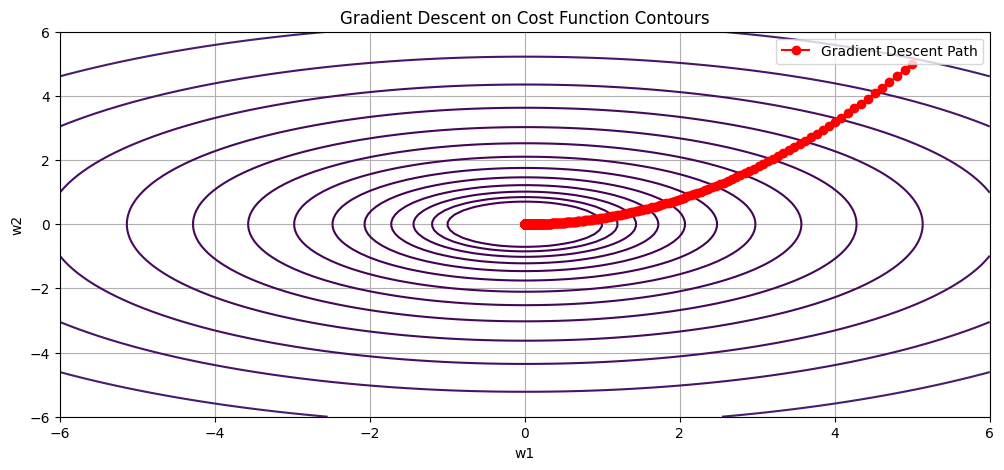

In [6]:
W_initial = [5.0, 5.0]
path_const = gradient_descent(W_initial, learning_rate=0.01, num_steps=1000)

w1_vals = np.linspace(-6, 6, 100)
w2_vals = np.linspace(-6, 6, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
J_vals = cost_function([W1, W2])


plt.figure(figsize=(12, 5))
contour_levels = np.logspace(0, 3, 20)
plt.contour(W1, W2, J_vals, levels=contour_levels, cmap='viridis')
path_x, path_y = path_const[:, 0], path_const[:, 1]
plt.plot(path_x, path_y, marker='o', color='red', label='Gradient Descent Path')
plt.title('Gradient Descent on Cost Function Contours')
plt.xlabel('w1')
plt.ylabel('w2')    
plt.legend()
plt.grid()
plt.show()

In [7]:
def run_gradient_descent_with_history(initial_w:list, learning_rate:float, num_steps:int) -> tuple:
    w = np.array(initial_w, dtype=float)
    path = [w.copy()]
    costs = [cost_function(w)]

    for _ in range(num_steps):
        grad = gradient_of_cost_function(w)
        w = w - learning_rate * grad
        path.append(w.copy())
        costs.append(cost_function(w))

    return np.array(path), np.array(costs)


def run_momentum_descent(initial_w:list, learning_rate:float, beta:float, num_steps:int) -> tuple:
    w = np.array(initial_w, dtype=float)
    velocity = np.zeros_like(w)
    path = [w.copy()]
    costs = [cost_function(w)]

    for _ in range(num_steps):
        grad = gradient_of_cost_function(w)
        velocity = beta * velocity + grad
        w = w - learning_rate * velocity
        path.append(w.copy())
        costs.append(cost_function(w))

    return np.array(path), np.array(costs)

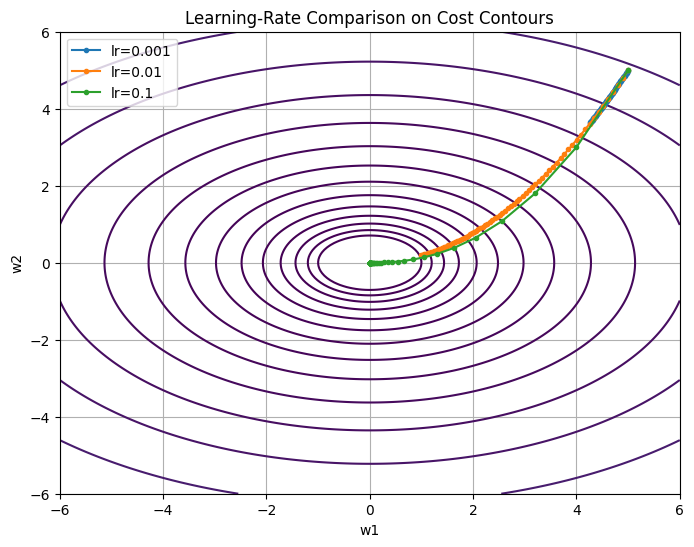

In [8]:
W_initial = [5.0, 5.0]
num_steps = 80
learning_rates = [0.001, 0.01, 0.1]

paths_by_lr = {}
costs_by_lr = {}
for lr in learning_rates:
    path, costs = run_gradient_descent_with_history(W_initial, lr, num_steps)
    paths_by_lr[lr] = path
    costs_by_lr[lr] = costs

w1_vals = np.linspace(-6, 6, 200)
w2_vals = np.linspace(-6, 6, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
J_vals = cost_function([W1, W2])

plt.figure(figsize=(8, 6))
contour_levels = np.logspace(0, 3, 20)
plt.contour(W1, W2, J_vals, levels=contour_levels, cmap='viridis')

for lr in learning_rates:
    path = paths_by_lr[lr]
    plt.plot(path[:, 0], path[:, 1], marker='o', markersize=3, linewidth=1.5, label=f'lr={lr}')

plt.title('Learning-Rate Comparison on Cost Contours')
plt.xlabel('w1')
plt.ylabel('w2')
plt.legend()
plt.grid(True)
plt.show()

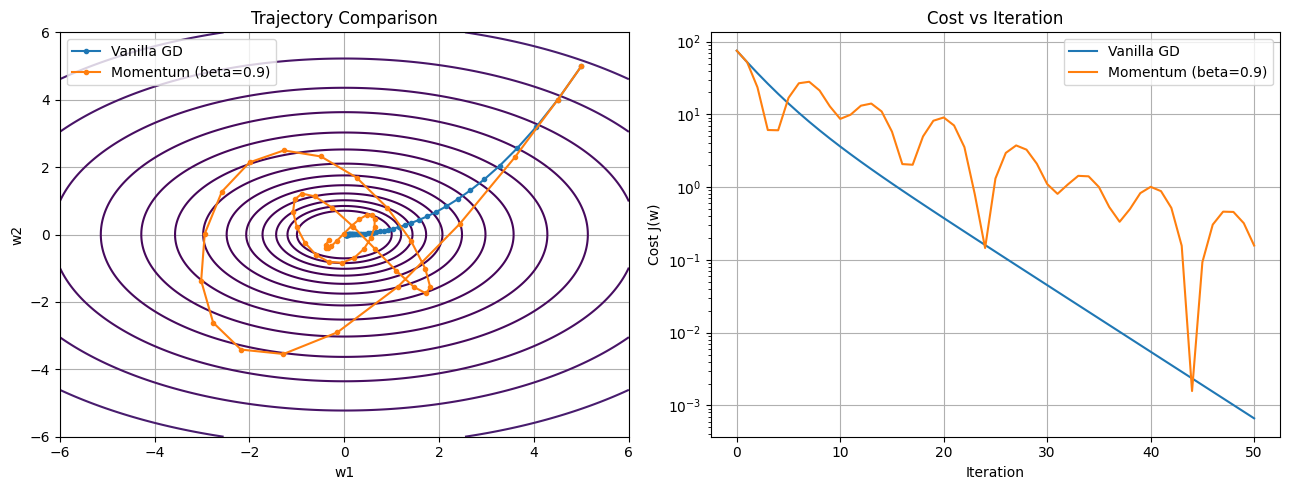

Final cost (Vanilla): 6.640452e-04
Final cost (Momentum): 1.576641e-01


In [9]:
# 3) Momentum vs vanilla gradient descent
comparison_lr = 0.05
beta = 0.9
comparison_steps = 50

vanilla_path, vanilla_costs = run_gradient_descent_with_history(W_initial, comparison_lr, comparison_steps)
momentum_path, momentum_costs = run_momentum_descent(W_initial, comparison_lr, beta, comparison_steps)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: trajectories on contour
axes[0].contour(W1, W2, J_vals, levels=contour_levels, cmap='viridis')
axes[0].plot(vanilla_path[:, 0], vanilla_path[:, 1], marker='o', markersize=3, linewidth=1.5, label='Vanilla GD')
axes[0].plot(momentum_path[:, 0], momentum_path[:, 1], marker='o', markersize=3, linewidth=1.5, label=f'Momentum (beta={beta})')
axes[0].set_title('Trajectory Comparison')
axes[0].set_xlabel('w1')
axes[0].set_ylabel('w2')
axes[0].legend()
axes[0].grid(True)

# Right: cost curves
axes[1].plot(np.maximum(vanilla_costs, 1e-15), label='Vanilla GD')
axes[1].plot(np.maximum(momentum_costs, 1e-15), label=f'Momentum (beta={beta})')
axes[1].set_yscale('log')
axes[1].set_title('Cost vs Iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost J(w)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Final cost (Vanilla): {vanilla_costs[-1]:.6e}')
print(f'Final cost (Momentum): {momentum_costs[-1]:.6e}')